# Merged-cell failure analysis

This notebook analyzes extracted 3D regions where multiple cells may have been merged into one detection.

## Objectives

1. Load all extracted failure cases and their metadata.
2. Inspect orthogonal slices and maximum-intensity projections.
3. Examine intensity variation through Z.
4. Generate a provisional local foreground mask.
5. Inspect the 3D distance transform and candidate cell centers.
6. Record structured diagnostic observations.

The current extraction files contain the **raw microscopy volume** and metadata. For a complete pipeline-stage comparison, later extraction runs should also save the matching binary-mask and watershed-label crops.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import ndimage as ndi
from skimage import filters, morphology
from skimage.feature import peak_local_max


## Locate the project root

This works whether the notebook kernel starts from the project root, `notebooks`, or `notebooks/diagnostics`.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        expected = candidate / "data" / "extracted" / "merged_cells"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Expected to find "
        "'data/extracted/merged_cells' in the current directory or one of its parents."
    )


PROJECT_ROOT = find_project_root()
CASES_DIR = PROJECT_ROOT / "data" / "extracted" / "merged_cells"
ANNOTATIONS_PATH = CASES_DIR / "diagnostic_annotations.csv"

print("Project root:", PROJECT_ROOT)
print("Cases directory:", CASES_DIR)


Project root: D:\Projects\Kaggle\cell-tracking
Cases directory: D:\Projects\Kaggle\cell-tracking\data\extracted\merged_cells


## Load the extracted cases

In [3]:
def load_cases(cases_dir: Path) -> pd.DataFrame:
    json_files = sorted(cases_dir.glob("*.json"))
    records = []

    for metadata_path in json_files:
        with metadata_path.open("r", encoding="utf-8") as file:
            metadata = json.load(file)

        volume_path = cases_dir / metadata_path.with_suffix(".npy").name

        records.append(
            {
                "sample_id": metadata.get("sample_id"),
                "frame": metadata.get("frame"),
                "cell_id": metadata.get("cell_id"),
                "box_size_zyx": metadata.get("box_size_zyx"),
                "centroid_zyx": metadata.get("centroid_zyx"),
                "volume_path": volume_path,
                "metadata_path": metadata_path,
                "volume_exists": volume_path.exists(),
            }
        )

    cases = pd.DataFrame(records)

    if cases.empty:
        raise FileNotFoundError(
            f"No extracted case metadata files were found in {cases_dir}"
        )

    return cases.sort_values(
        ["sample_id", "frame", "cell_id"]
    ).reset_index(drop=True)


cases = load_cases(CASES_DIR)
cases


,sample_id,frame,cell_id,box_size_zyx,centroid_zyx,volume_path,metadata_path,volume_exists
0,44b6_0113de3b,9,137,"[17, 65, 65]","[42.17970858067998, 38.91419320021587, 169.977...",D:\Projects\Kaggle\cell-tracking\data\extracte...,D:\Projects\Kaggle\cell-tracking\data\extracte...,True
1,44b6_0113de3b,13,151,"[12, 50, 50]","[43.53904146472806, 48.948303715670434, 169.44...",D:\Projects\Kaggle\cell-tracking\data\extracte...,D:\Projects\Kaggle\cell-tracking\data\extracte...,True
2,44b6_0113de3b,19,61,"[12, 50, 50]","[12.291470434327575, 227.2443746729461, 68.418...",D:\Projects\Kaggle\cell-tracking\data\extracte...,D:\Projects\Kaggle\cell-tracking\data\extracte...,True


## Select a case

Change `CASE_INDEX` to inspect another row from the table above.


In [4]:
CASE_INDEX = 0

case = cases.iloc[CASE_INDEX]

with case["metadata_path"].open("r", encoding="utf-8") as file:
    metadata = json.load(file)

volume = np.load(case["volume_path"])

print(
    f"Sample={case['sample_id']} | "
    f"frame={case['frame']} | "
    f"cell_id={case['cell_id']}"
)
print("Volume shape:", volume.shape)
print("Data type:", volume.dtype)
print("Intensity range:", int(volume.min()), "to", int(volume.max()))
print("Centroid:", metadata.get("centroid_zyx"))


Sample=44b6_0113de3b | frame=9 | cell_id=137
Volume shape: (17, 65, 65)
Data type: uint16
Intensity range: 105 to 2696
Centroid: [42.17970858067998, 38.91419320021587, 169.97787371829466]


## Robust intensity normalization

In [5]:
def robust_normalize(
    image: np.ndarray,
    lower_percentile: float = 1.0,
    upper_percentile: float = 99.5,
) -> np.ndarray:
    image = image.astype(np.float32)

    low, high = np.percentile(
        image,
        [lower_percentile, upper_percentile],
    )

    if high <= low:
        return np.zeros_like(image, dtype=np.float32)

    normalized = (image - low) / (high - low)
    return np.clip(normalized, 0.0, 1.0)


normalized = robust_normalize(volume)


## Orthogonal maximum-intensity projections

These projections help reveal whether the crop contains one compact body, two lobes, an oblique bridge, or an internal intensity valley.


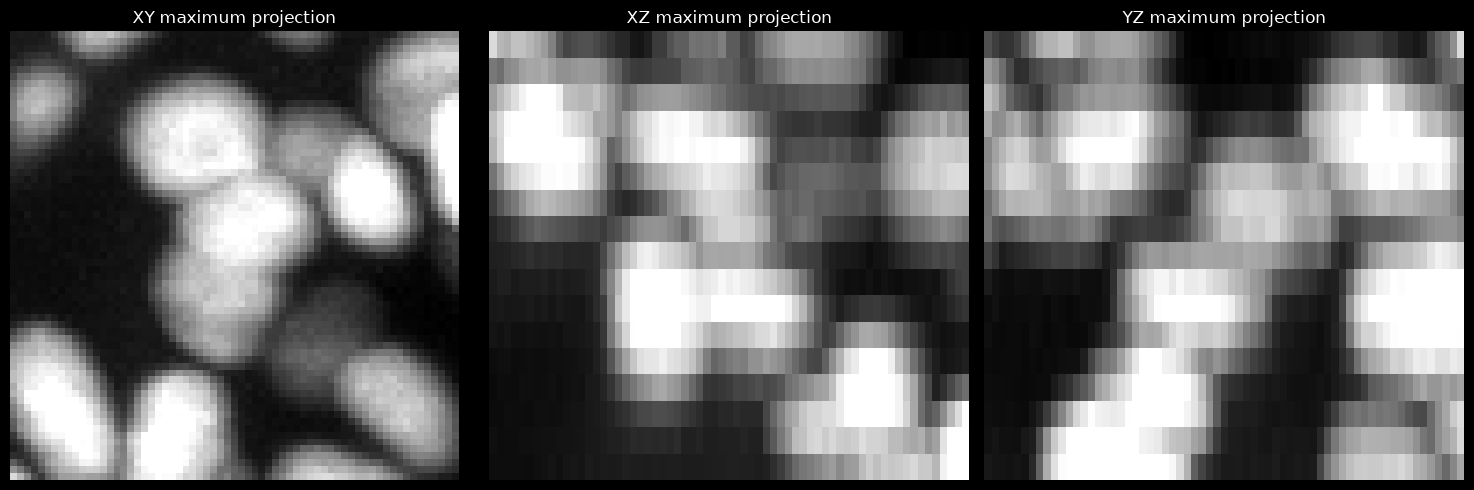

In [6]:
mip_xy = normalized.max(axis=0)
mip_xz = normalized.max(axis=1)
mip_yz = normalized.max(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mip_xy, cmap="gray")
axes[0].set_title("XY maximum projection")

axes[1].imshow(mip_xz, cmap="gray", aspect="auto")
axes[1].set_title("XZ maximum projection")

axes[2].imshow(mip_yz, cmap="gray", aspect="auto")
axes[2].set_title("YZ maximum projection")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()


## Central orthogonal slices

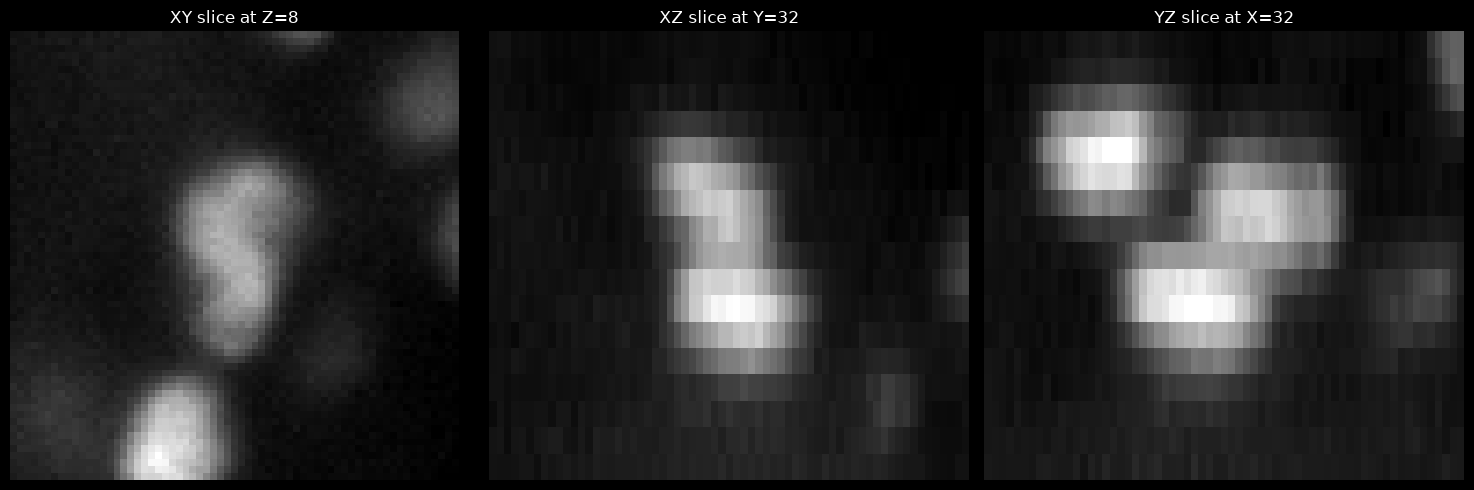

In [7]:
z_mid, y_mid, x_mid = np.asarray(normalized.shape) // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(normalized[z_mid], cmap="gray")
axes[0].set_title(f"XY slice at Z={z_mid}")

axes[1].imshow(normalized[:, y_mid, :], cmap="gray", aspect="auto")
axes[1].set_title(f"XZ slice at Y={y_mid}")

axes[2].imshow(normalized[:, :, x_mid], cmap="gray", aspect="auto")
axes[2].set_title(f"YZ slice at X={x_mid}")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()


## Intensity variation through Z

Changes in mean intensity, maximum intensity, and contrast can indicate slices where touching structures become distinguishable.


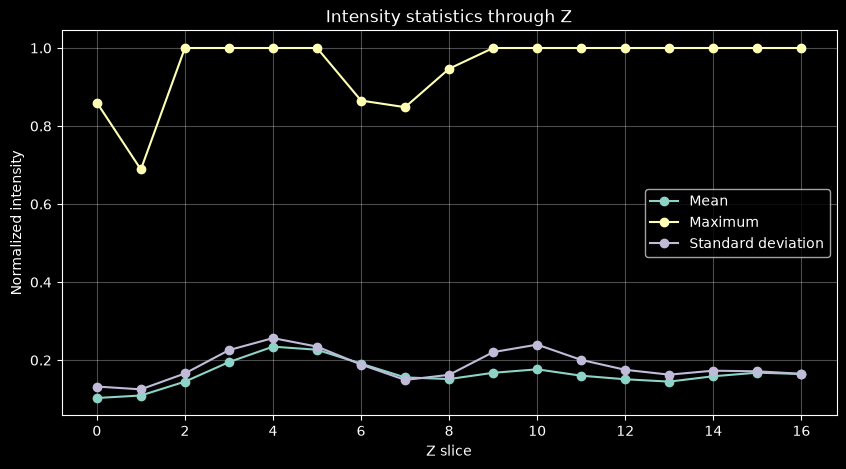

In [8]:
slice_mean = normalized.mean(axis=(1, 2))
slice_max = normalized.max(axis=(1, 2))
slice_std = normalized.std(axis=(1, 2))

z_indices = np.arange(normalized.shape[0])

plt.figure(figsize=(10, 5))
plt.plot(z_indices, slice_mean, marker="o", label="Mean")
plt.plot(z_indices, slice_max, marker="o", label="Maximum")
plt.plot(z_indices, slice_std, marker="o", label="Standard deviation")
plt.xlabel("Z slice")
plt.ylabel("Normalized intensity")
plt.title("Intensity statistics through Z")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Provisional local foreground mask

This is a diagnostic local mask, not an exact reproduction of the production masking stage.


In [9]:
smoothed = filters.gaussian(
    normalized,
    sigma=(0.6, 1.0, 1.0),
    preserve_range=True,
)

positive_values = smoothed[smoothed > 0]

if positive_values.size == 0:
    raise ValueError("The selected crop contains no positive intensity values.")

threshold = filters.threshold_otsu(positive_values)
local_mask = smoothed >= threshold

local_mask = morphology.remove_small_objects(
    local_mask,
    min_size=20,
)

connected_labels, connected_count = ndi.label(local_mask)

print("Local Otsu threshold:", threshold)
print("Connected foreground components:", connected_count)
print("Foreground voxels:", int(local_mask.sum()))


Local Otsu threshold: 0.3337632020009291
Connected foreground components: 13
Foreground voxels: 9450


C:\Users\User\AppData\Local\Temp\ipykernel_21656\637487942.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  local_mask = morphology.remove_small_objects(


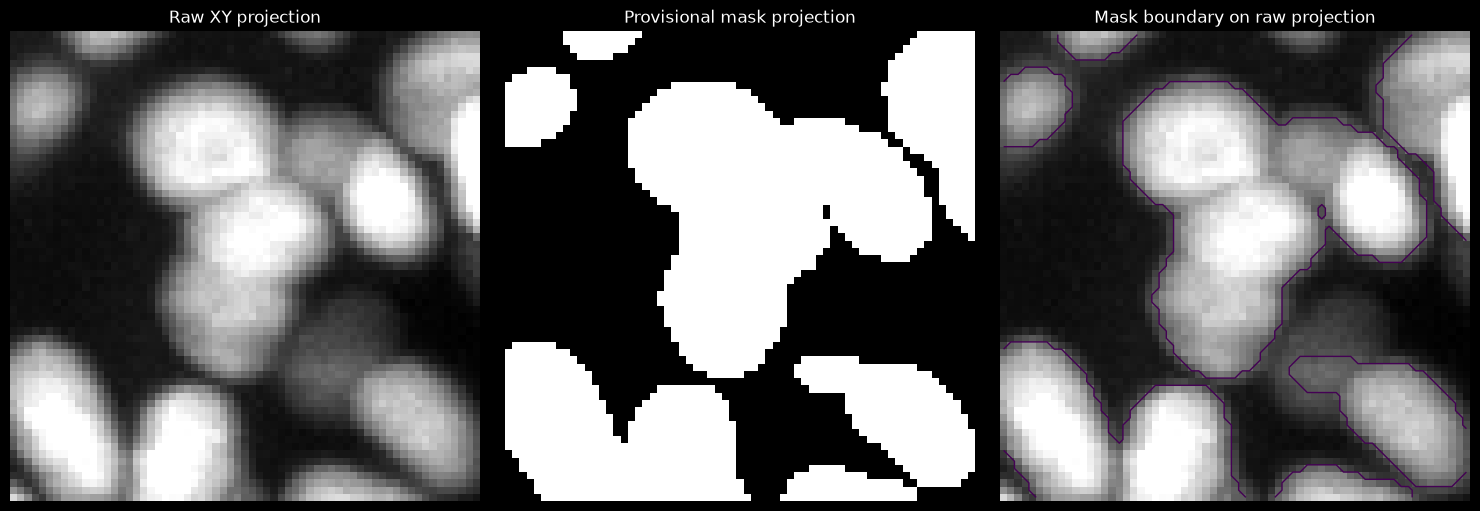

In [10]:
mask_mip = local_mask.max(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mip_xy, cmap="gray")
axes[0].set_title("Raw XY projection")

axes[1].imshow(mask_mip, cmap="gray")
axes[1].set_title("Provisional mask projection")

axes[2].imshow(mip_xy, cmap="gray")
axes[2].contour(mask_mip, levels=[0.5], linewidths=1)
axes[2].set_title("Mask boundary on raw projection")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()


## Distance transform and candidate centers

Multiple meaningful peaks inside one connected object are evidence that the region may contain multiple cell bodies.


In [11]:
VOXEL_SIZE_ZYX = tuple(
    metadata.get(
        "voxel_size_zyx",
        [1.625, 0.40625, 0.40625],
    )
)

distance = ndi.distance_transform_edt(
    local_mask,
    sampling=VOXEL_SIZE_ZYX,
)

peak_coordinates = peak_local_max(
    distance,
    labels=local_mask,
    min_distance=3,
    threshold_rel=0.25,
    exclude_border=False,
)

print("Candidate distance-transform peaks:", len(peak_coordinates))
print(peak_coordinates)


Candidate distance-transform peaks: 17
[[ 4 15 28]
 [10 28 33]
 [ 5  5 64]
 [ 9 62 23]
 [10 57 24]
 [ 4 51  4]
 [ 6 36 31]
 [14 23 51]
 [ 4 61 10]
 [16 53 56]
 [ 0 17 43]
 [15 14 64]
 [14 64 44]
 [ 0 10  3]
 [ 2  0 12]
 [ 0 64 29]
 [ 5 47 44]]


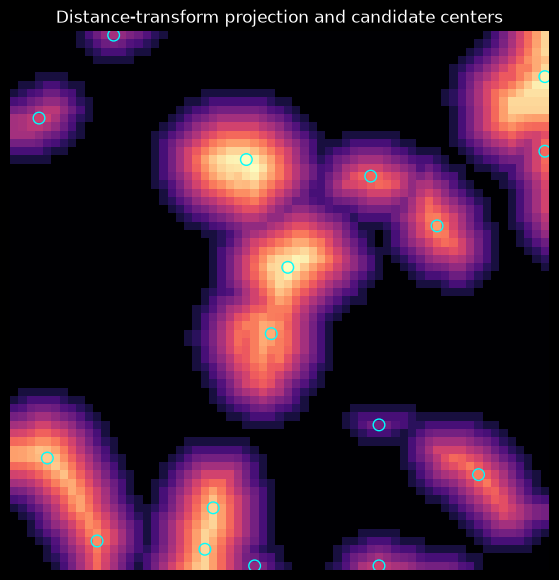

In [12]:
distance_mip = distance.max(axis=0)

plt.figure(figsize=(7, 7))
plt.imshow(distance_mip, cmap="magma")

for z, y, x in peak_coordinates:
    plt.scatter(x, y, s=70, facecolors="none", edgecolors="cyan")

plt.title("Distance-transform projection and candidate centers")
plt.axis("off")
plt.show()


## Per-slice connected-component count

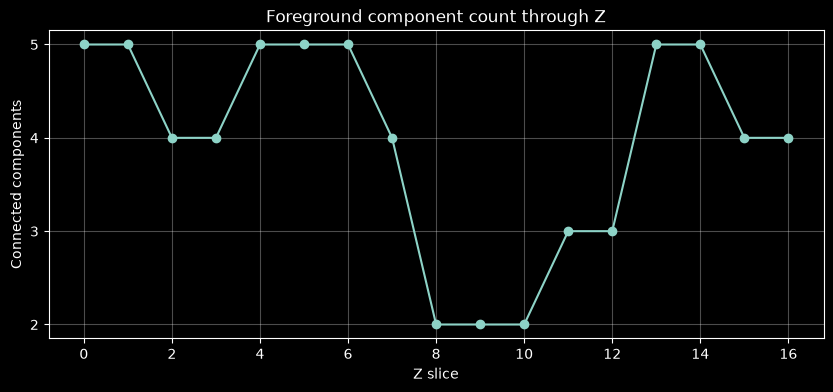

In [13]:
component_counts = []

for z in range(local_mask.shape[0]):
    _, count = ndi.label(local_mask[z])
    component_counts.append(count)

plt.figure(figsize=(10, 4))
plt.plot(
    np.arange(len(component_counts)),
    component_counts,
    marker="o",
)
plt.xlabel("Z slice")
plt.ylabel("Connected components")
plt.title("Foreground component count through Z")
plt.yticks(sorted(set(component_counts)))
plt.grid(alpha=0.3)
plt.show()


## Optional 3D inspection in Napari

Uncomment and run this cell for interactive inspection.


In [15]:
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(
    normalized,
    name="Raw crop",
    scale=VOXEL_SIZE_ZYX,
)
viewer.add_labels(
    local_mask.astype(np.uint8),
    name="Provisional mask",
    scale=VOXEL_SIZE_ZYX,
    opacity=0.35,
)
viewer.add_image(
    distance,
    name="Distance transform",
    scale=VOXEL_SIZE_ZYX,
    opacity=0.5,
    visible=False,
)

if len(peak_coordinates) > 0:
    viewer.add_points(
        peak_coordinates,
        name="Candidate centers",
        scale=VOXEL_SIZE_ZYX,
        size=3,
        face_color="cyan",
    )

napari.run()


## Record diagnostic observations

Suggested values:

- `expected_cell_count`: `1`, `2`, `3`, or `uncertain`
- `visible_intensity_valley`: `yes`, `no`, or `uncertain`
- `failure_type`: `merged_touching_cells`, `mask_bridge`, `watershed_marker_failure`, or `uncertain`


In [16]:
annotation = {
    "sample_id": case["sample_id"],
    "frame": int(case["frame"]),
    "cell_id": int(case["cell_id"]),
    "expected_cell_count": "uncertain",
    "visible_intensity_valley": "uncertain",
    "multiple_distance_peaks": (
        "yes" if len(peak_coordinates) >= 2 else "no"
    ),
    "connected_components_local_mask": int(connected_count),
    "distance_peak_count": int(len(peak_coordinates)),
    "failure_type": "uncertain",
    "notes": "",
}

annotation


{'sample_id': '44b6_0113de3b',
 'frame': 9,
 'cell_id': 137,
 'expected_cell_count': 'uncertain',
 'visible_intensity_valley': 'uncertain',
 'multiple_distance_peaks': 'yes',
 'connected_components_local_mask': 13,
 'distance_peak_count': 17,
 'failure_type': 'uncertain',
 'notes': ''}

In [17]:
def save_annotation(
    annotation: dict,
    output_path: Path = ANNOTATIONS_PATH,
) -> pd.DataFrame:
    new_row = pd.DataFrame([annotation])

    if output_path.exists():
        existing = pd.read_csv(output_path)
        combined = pd.concat(
            [existing, new_row],
            ignore_index=True,
        )
    else:
        combined = new_row

    combined = combined.drop_duplicates(
        subset=["sample_id", "frame", "cell_id"],
        keep="last",
    ).sort_values(
        ["sample_id", "frame", "cell_id"]
    )

    combined.to_csv(output_path, index=False)
    return combined


# After editing the annotation dictionary above, uncomment:
#
# annotations = save_annotation(annotation)
# annotations


## Recommended extraction improvement

For future cases, save aligned crops from these stages:

```text
raw.npy
preprocessed.npy
binary_mask.npy
watershed_labels.npy
metadata.json
```

That will let us determine whether the failure was introduced during preprocessing, thresholding, marker generation, watershed segmentation, or later filtering.
